YAML path: C:\Users\roz31\Documents\GitHub\KNdata-public\caves_fulldatasets\data\001_GouffreDejaVu_000\001_GouffreDejaVu_000.yaml
Exists? True

Top-level YAML keys: ['metadata', 'edges', 'node_attributes']

Graph summary:
number of nodes = 40
number of edges = 32

Metadata:
id_dataset = 001
short_name = GouffreDejaVu
id_subset = 000
status = clean
type_of_correction = no correction
last_processing_date = 11 Nov 2025
license = CC BY-NC-SA 4.0
citation = Centre Terre. (2024). Survey Data for the Ultima Patagonia Cave Exploration project [Dataset]. https://github.com/tr1813/ultima-patag
thanks = nan
sharing_conditions = nan
total_length = 150
total_depth = 32.16
percentage_csdim = 100
number_connected_components = 1
number_nodes = 33
number_edges = 32
mean_degree = 1.5
min_degree = 1.0
max_degree = 3.0
cv_degree = 0.667
number_cycles = 0
mean_length = 50.23
cv_length = 0.96
length_entropy = 0.48
orientation_3d_entropy = 0.597
aspl = 1.5
cpd = 1.0
correlation_vertex_degree = -1.0
original_

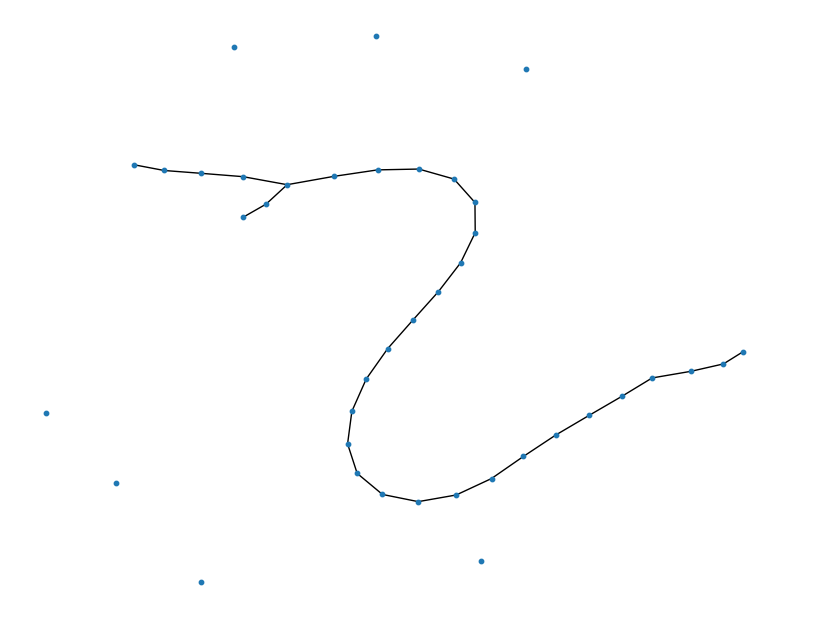

In [1]:
from pathlib import Path
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import yaml

# --------------------------------------------------
# Paths
# --------------------------------------------------
REPO = Path.home() / "Documents" / "GitHub" / "KNdata-public"
DATA_ROOT = REPO / "caves_fulldatasets"
summary_file = DATA_ROOT / "caves_properties_summary.csv"

# --------------------------------------------------
# Read summary
# --------------------------------------------------
table_caves = pd.read_csv(
    summary_file,
    sep=";",
    index_col=1,
    dtype={"id_subset": str, "id_dataset": str},
)

# --------------------------------------------------
# Select cave
# --------------------------------------------------
cavename = "GouffreDejaVu"
id_dataset = table_caves.loc[cavename, "id_dataset"]
id_subset = table_caves.loc[cavename, "id_subset"]

yaml_folder = DATA_ROOT / "data" / f"{id_dataset}_{cavename}_{id_subset}"
path_to_yaml = yaml_folder / f"{id_dataset}_{cavename}_{id_subset}.yaml"

print("YAML path:", path_to_yaml)
print("Exists?", path_to_yaml.exists())

# --------------------------------------------------
# Load YAML
# --------------------------------------------------
with open(path_to_yaml, "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

print("\nTop-level YAML keys:", list(data.keys()))

# --------------------------------------------------
# Build graph
# --------------------------------------------------
G = nx.Graph()

# --- Nodes ---
node_attrs = data.get("node_attributes", {})
for node, attrs in node_attrs.items():
    if isinstance(attrs, dict):
        clean_attrs = {str(k): v for k, v in attrs.items()}
        G.add_node(node, **clean_attrs)
    else:
        G.add_node(node)

# --- Edges ---
edges = data.get("edges", [])
for e in edges:
    if isinstance(e, dict):
        u = e.get("u") or e.get("source")
        v = e.get("v") or e.get("target")

        clean_attrs = {
            str(k): val for k, val in e.items()
            if k not in ["u", "v", "source", "target"]
        }

        if u is not None and v is not None:
            G.add_edge(u, v, **clean_attrs)

    elif isinstance(e, (list, tuple)) and len(e) >= 2:
        G.add_edge(e[0], e[1])

# --- Metadata ---
meta = data.get("metadata", {})
for k, v in meta.items():
    G.graph[str(k)] = v

# --------------------------------------------------
# Print summary
# --------------------------------------------------
print("\nGraph summary:")
print("number of nodes =", G.number_of_nodes())
print("number of edges =", G.number_of_edges())

print("\nMetadata:")
for k, v in G.graph.items():
    print(k, "=", v)

# --------------------------------------------------
# Plot
# --------------------------------------------------
if G.number_of_nodes() > 0:
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=1)
    nx.draw(G, pos, node_size=10, with_labels=False)
    plt.show()
else:
    print("\nNo graph was built — send me print(data) if this happens.")

YAML path: C:\Users\roz31\Documents\GitHub\KNdata-public\caves_fulldatasets\data\001_GouffreDejaVu_000\001_GouffreDejaVu_000.yaml
Exists? True

Top-level YAML keys: ['metadata', 'edges', 'node_attributes']

Graph summary:
number of nodes = 40
number of edges = 32

Metadata:
id_dataset = 001
short_name = GouffreDejaVu
id_subset = 000
status = clean
type_of_correction = no correction
last_processing_date = 11 Nov 2025
license = CC BY-NC-SA 4.0
citation = Centre Terre. (2024). Survey Data for the Ultima Patagonia Cave Exploration project [Dataset]. https://github.com/tr1813/ultima-patag
thanks = nan
sharing_conditions = nan
total_length = 150
total_depth = 32.16
percentage_csdim = 100
number_connected_components = 1
number_nodes = 33
number_edges = 32
mean_degree = 1.5
min_degree = 1.0
max_degree = 3.0
cv_degree = 0.667
number_cycles = 0
mean_length = 50.23
cv_length = 0.96
length_entropy = 0.48
orientation_3d_entropy = 0.597
aspl = 1.5
cpd = 1.0
correlation_vertex_degree = -1.0
original_

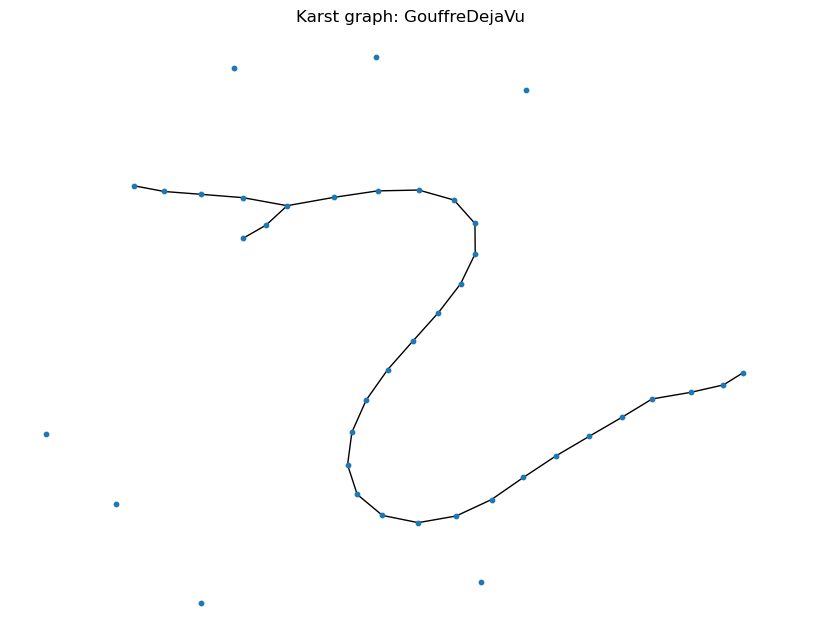

In [2]:
from pathlib import Path
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import yaml
import numpy as np

# --------------------------------------------------
# Spectral invariants for a Karst graph
# --------------------------------------------------
def spectral_invariants(G, tol=1e-9):
    if G.number_of_nodes() == 0:
        raise ValueError("Graph is empty.")

    # keep only largest connected component if needed
    if not nx.is_connected(G):
        largest_cc = max(nx.connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()
        print("\nGraph was disconnected; invariants computed on largest connected component.")

    nodes = list(G.nodes())
    n = len(nodes)
    m = G.number_of_edges()

    A = nx.to_numpy_array(G, nodelist=nodes, dtype=float)
    L = nx.laplacian_matrix(G, nodelist=nodes).toarray().astype(float)
    degrees = A.sum(axis=1)
    D = np.diag(degrees)
    Q = D + A

    # normalized Laplacian
    D_inv_sqrt = np.zeros((n, n), dtype=float)
    for i in range(n):
        if degrees[i] > tol:
            D_inv_sqrt[i, i] = 1.0 / np.sqrt(degrees[i])
    Lnorm = np.eye(n) - D_inv_sqrt @ A @ D_inv_sqrt

    # eigenvalues
    adj_eigs = np.sort(np.linalg.eigvalsh(A))[::-1]
    lap_eigs = np.sort(np.linalg.eigvalsh(L))
    q_eigs = np.sort(np.linalg.eigvalsh(Q))
    norm_lap_eigs = np.sort(np.linalg.eigvalsh(Lnorm))

    spectral_radius = float(np.max(np.abs(adj_eigs)))
    algebraic_connectivity = float(lap_eigs[1]) if n >= 2 else 0.0
    normalized_algebraic_connectivity = float(norm_lap_eigs[1]) if n >= 2 else 0.0
    graph_energy = float(np.sum(np.abs(adj_eigs)))
    avg_degree = 2 * m / n
    laplacian_energy = float(np.sum(np.abs(lap_eigs - avg_degree)))
    estrada_index = float(np.sum(np.exp(adj_eigs)))

    positive_lap_eigs = lap_eigs[lap_eigs > tol]
    kirchhoff_index = float(n * np.sum(1.0 / positive_lap_eigs)) if len(positive_lap_eigs) == n - 1 else np.nan

    # spanning trees via Matrix-Tree theorem
    L_minor = L[1:, 1:]
    num_spanning_trees = round(np.linalg.det(L_minor))

    pos_inertia = int(np.sum(adj_eigs > tol))
    zero_inertia = int(np.sum(np.abs(adj_eigs) <= tol))
    neg_inertia = int(np.sum(adj_eigs < -tol))

    return {
        "n": n,
        "m": m,
        "spectral_radius": spectral_radius,
        "algebraic_connectivity": algebraic_connectivity,
        "normalized_algebraic_connectivity": normalized_algebraic_connectivity,
        "graph_energy": graph_energy,
        "laplacian_energy": laplacian_energy,
        "estrada_index": estrada_index,
        "kirchhoff_index": kirchhoff_index,
        "num_spanning_trees": num_spanning_trees,
        "adjacency_inertia": (pos_inertia, zero_inertia, neg_inertia),
        "adjacency_eigenvalues": adj_eigs,
        "laplacian_eigenvalues": lap_eigs,
        "signless_laplacian_eigenvalues": q_eigs,
        "normalized_laplacian_eigenvalues": norm_lap_eigs,
    }

# --------------------------------------------------
# Paths
# --------------------------------------------------
REPO = Path.home() / "Documents" / "GitHub" / "KNdata-public"
DATA_ROOT = REPO / "caves_fulldatasets"
summary_file = DATA_ROOT / "caves_properties_summary.csv"

# --------------------------------------------------
# Read summary
# --------------------------------------------------
table_caves = pd.read_csv(
    summary_file,
    sep=";",
    index_col=1,
    dtype={"id_subset": str, "id_dataset": str},
)

# --------------------------------------------------
# Select cave
# --------------------------------------------------
cavename = "GouffreDejaVu"
id_dataset = table_caves.loc[cavename, "id_dataset"]
id_subset = table_caves.loc[cavename, "id_subset"]

yaml_folder = DATA_ROOT / "data" / f"{id_dataset}_{cavename}_{id_subset}"
path_to_yaml = yaml_folder / f"{id_dataset}_{cavename}_{id_subset}.yaml"

print("YAML path:", path_to_yaml)
print("Exists?", path_to_yaml.exists())

# --------------------------------------------------
# Load YAML
# --------------------------------------------------
with open(path_to_yaml, "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

print("\nTop-level YAML keys:", list(data.keys()))

# --------------------------------------------------
# Build graph
# --------------------------------------------------
G = nx.Graph()

# --- Nodes ---
node_attrs = data.get("node_attributes", {})
for node, attrs in node_attrs.items():
    if isinstance(attrs, dict):
        clean_attrs = {str(k): v for k, v in attrs.items()}
        G.add_node(node, **clean_attrs)
    else:
        G.add_node(node)

# --- Edges ---
edges = data.get("edges", [])
for e in edges:
    if isinstance(e, dict):
        u = e.get("u") or e.get("source")
        v = e.get("v") or e.get("target")

        clean_attrs = {
            str(k): val for k, val in e.items()
            if k not in ["u", "v", "source", "target"]
        }

        if u is not None and v is not None:
            G.add_edge(u, v, **clean_attrs)

    elif isinstance(e, (list, tuple)) and len(e) >= 2:
        G.add_edge(e[0], e[1])

# --- Metadata ---
meta = data.get("metadata", {})
for k, v in meta.items():
    G.graph[str(k)] = v

# --------------------------------------------------
# Print summary
# --------------------------------------------------
print("\nGraph summary:")
print("number of nodes =", G.number_of_nodes())
print("number of edges =", G.number_of_edges())

print("\nMetadata:")
for k, v in G.graph.items():
    print(k, "=", v)

# --------------------------------------------------
# Compute spectral invariants
# --------------------------------------------------
inv = spectral_invariants(G)

print("\nSpectral invariants:")
for key in [
    "n",
    "m",
    "spectral_radius",
    "algebraic_connectivity",
    "normalized_algebraic_connectivity",
    "graph_energy",
    "laplacian_energy",
    "estrada_index",
    "kirchhoff_index",
    "num_spanning_trees",
    "adjacency_inertia",
]:
    print(f"{key} = {inv[key]}")

print("\nLargest adjacency eigenvalues:")
print(inv["adjacency_eigenvalues"][:10])

print("\nSmallest Laplacian eigenvalues:")
print(inv["laplacian_eigenvalues"][:10])

# --------------------------------------------------
# Plot
# --------------------------------------------------
if G.number_of_nodes() > 0:
    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=1)
    nx.draw(G, pos, node_size=10, with_labels=False)
    plt.title(f"Karst graph: {cavename}")
    plt.show()
else:
    print("\nNo graph was built — send me print(data) if this happens.")